In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import time
import gdsfactory as gf
# gf.gpdk.PDK.activate()

sys.path.append(r"D:\Ligentic_NU_1_TapeOut_April2026\Ligentec_NU_1_Layout")
from Racetrack import Racetrack
from Straight import Straight
from IO2 import IO2

%matplotlib widget
import mplcursors
from mpl_interactions import zoom_factory

from plot_utils import copy_fig_to_clipboard

# --------------------------------------------------
# Paths
# --------------------------------------------------
WORKDIR   = Path().resolve()
REPO_ROOT = WORKDIR.parents[2]
os.chdir(WORKDIR)

data_folder   = REPO_ROOT / "results_data" / "Data_RingRaceTrack"
data_save_dir = data_folder
data_save_dir.mkdir(parents=True, exist_ok=True)

print("Repo root  :", REPO_ROOT)
print("Data folder:", data_folder)
print("Data folder exists:", data_folder.exists())
print("Working dir:", WORKDIR)

sys.path.append(r'C:\Program Files\ANSYS Inc\v251\Lumerical\api\python') # QP5 Lumerical API path
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')  #QP3 Lumerical API path
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')  #QP2 Lumerical API path



Repo root  : D:\Ligentic_NU_1_TapeOut_April2026
Data folder: D:\Ligentic_NU_1_TapeOut_April2026\results_data\Data_RingRaceTrack
Data folder exists: True
Working dir: D:\Ligentic_NU_1_TapeOut_April2026\scripts\directional_coupler\Verification_Kex_J


In [2]:
import lumapi as lm
try:
    f.redraw()  # Test if 'f' is already active
except NameError:
    print("Starting new Lumerical MODE session...")
    f = lm.MODE()  
except AttributeError:
    print("Reinitializing Lumerical MODE session...")
    f = lm.MODE()  

# Check if f is valid
if f is None:
    raise RuntimeError("Failed to initialize Lumerical MODE session. Check your Lumerical")

LumFileName = "RaceTrack_ADF.lms" # save .lms file
f.save(LumFileName)
f.switchtolayout()
f.selectall()
f.delete()


Starting new Lumerical MODE session...


C:\Program Files\ANSYS Inc\v251\Lumerical\api\python\lumapi.py:895: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


In [ ]:
#------------------------------------------------------------
# PARAMETERS
#------------------------------------------------------------
LambdaStart     = 1540E-9
LambdaStop      = 1560E-9

Width           = 1000E-9
Height          = 800E-9
Radius          = 20E-6
Gap             = 300E-9
Length          = 4 * Radius
CouplingLengthX = 12E-6
CouplingLengthY = 12E-6

decay_time         = 1E-4
Material           = "Si3N4 (Silicon Nitride) - Luke"
BackgroundMaterial = "SiO2 (Glass) - Palik"
use_index          = True
Index              = 1.97; #optional
SimulationTime     = 1200E-12

Euler              = 0

FrequencyPoints    = round(1000 * (LambdaStop - LambdaStart) * 1E9)
print(f"Frequency Points: {FrequencyPoints}")


Frequency Points: 20000


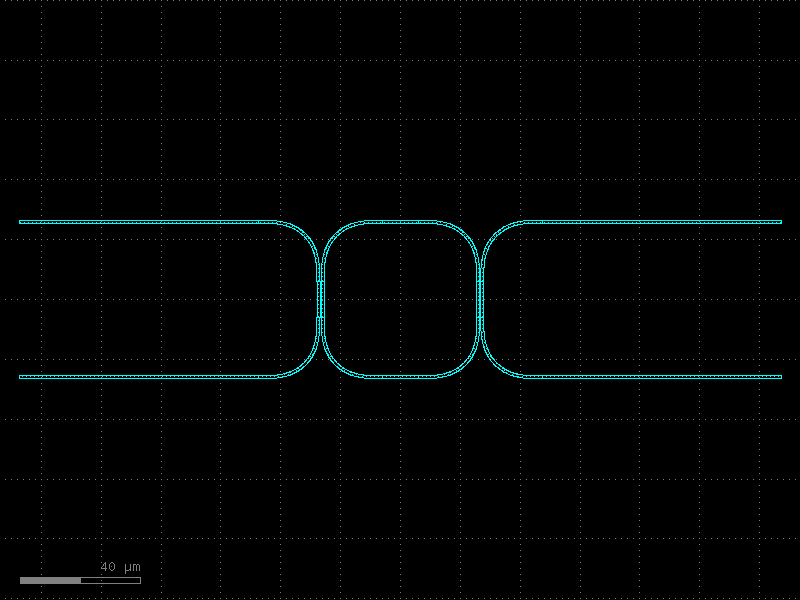

In [4]:
gf.clear_cache()

RaceTrack_ADF_U = gf.Component("RaceTrack_ADF_U")

IOLengthX = 100 #um

ring = RaceTrack_ADF_U << Racetrack(
    LengthX=CouplingLengthX*1e6, LengthY=CouplingLengthY*1e6,
    BendRadius=Radius*1e6, WgWidth=Width*1e6, Euler=1, Layer=(2,0)
)

XOffset = -IOLengthX-(Width+Gap+Radius+CouplingLengthX/2)*1e6
YOffset = (Radius+(CouplingLengthY/2))*1e6

WgUp  = RaceTrack_ADF_U << IO2(TotLengthX=IOLengthX,FAGap = (CouplingLengthY+2*Radius)*1e6 ,BendRadius = Radius*1e6,WgWidth = Width*1e6,Euler = 1,Layer = (2,0))
WgBot = RaceTrack_ADF_U << IO2(TotLengthX=IOLengthX,FAGap = (CouplingLengthY+2*Radius)*1e6 ,BendRadius = Radius*1e6,WgWidth = Width*1e6,Euler = 1,Layer = (2,0))
WgBot.mirror_x(0)
WgUp.move((XOffset,  YOffset ))
WgBot.move((-XOffset,  YOffset))

RaceTrack_ADF_U.write_gds("racetrack_ADF_U.gds")
RaceTrack_ADF_U.plot()

In [ ]:
f.gdsimport("racetrack_ADF_U.gds", "RaceTrack_ADF_U", "2:0", Material, 0, Height)

if use_index:
    f.set("material", "<Object defined dielectric>")
    f.set("index", Index)


18.0

In [6]:

WgPosY        = (Radius+(CouplingLengthY/2)) # meters

SpanX = 3 * (Radius + CouplingLengthX) + 10*Width
SpanY = 2 * (WgPosY + 3*Width)

SourcePosX    = -SpanX/2 + 2*Width
DrMonitorPosX = SpanX/2 - 2*Width

#------------------------------------------------------------
# varFDTD
#------------------------------------------------------------

f.addvarfdtd()
f.set("x0",CouplingLengthX/2+ Radius)
f.set("y0",0)
f.set("x", 0);          f.set("x span", SpanX)
f.set("y", 0);          f.set("y span", SpanY)
f.set("z", Height/2);   f.set("z span", 8*Height)

f.set("simulation time", SimulationTime)
f.set("background material", BackgroundMaterial)
f.set("set simulation bandwidth", 1)
f.set("bandwidth", "broadband")
f.set("simulation wavelength min", LambdaStart)
f.set("simulation wavelength max", LambdaStop)
f.set("auto shutoff min", decay_time)

f.set("x min bc", "PML"); f.set("x max bc", "PML")
f.set("y min bc", "PML"); f.set("y max bc", "PML")
f.set("z min bc", "PML"); f.set("z max bc", "PML")

# Test points on ring (45°, 135°, 225°, 315°)
theta = [2, 90,180,270]
test_points = np.array([
    [(Radius+CouplingLengthX/2) * np.cos(np.radians(t)) for t in theta],
    [(Radius+CouplingLengthY/2) * np.sin(np.radians(t)) for t in theta]
])
f.set("test points", test_points)

#------------------------------------------------------------
# Mode Source
#------------------------------------------------------------

f.addmodesource()
f.set("name", "ModeSource")
f.set("x", SourcePosX)  # Aligned with the right ring
f.set("y",  WgPosY)
f.set("y span", 2 * Width)
f.set("use relative coordinates", 1)
f.set("injection axis", "x-axis")
f.set("direction", "Forward")
f.set("amplitude", 1.0)
f.set("phase", 0)
f.set("mode selection", "fundamental mode")
f.set("set wavelength", 1)
f.set("wavelength start", LambdaStart)
f.set("wavelength stop", LambdaStop)

#------------------------------------------------------------
# Monitors
#------------------------------------------------------------

# THROUGH - output end of WgUp
f.adddftmonitor()
f.set("name", "Drop")
f.set("monitor type", "Linear Y")
f.set("x",  DrMonitorPosX)
f.set("y",  WgPosY)
f.set("y span", 4*Width)
f.set("z", Height/2)
f.set("override global monitor settings", 1)
f.set("use source limits", 1)
f.set("frequency points", FrequencyPoints)

# DROP - output end of WgBot
f.adddftmonitor()
f.set("name", "Through")
f.set("monitor type", "Linear Y")
f.set("x",  SourcePosX)
f.set("y", -WgPosY)
f.set("y span", 4*Width)
f.set("z", Height/2)
f.set("override global monitor settings", 1)
f.set("use source limits", 1)
f.set("frequency points", FrequencyPoints)

In [7]:
#------------------------------------------------------------
# Run
#------------------------------------------------------------
f.run()

✅ Copied.


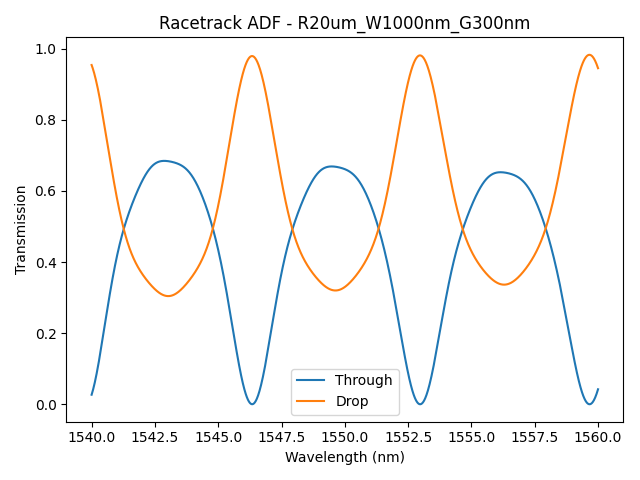

✅ Copied.


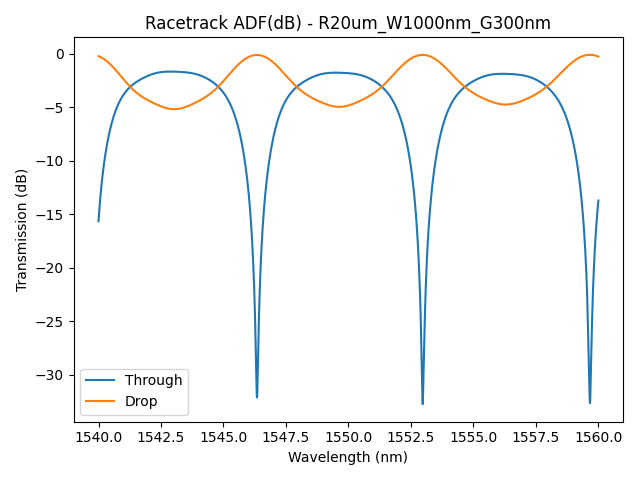

In [ ]:
fname     = data_save_dir / f"RaceTrackADF_U_R{Radius*1e6:.0f}um_W{Width*1e9:.0f}nm_G{Gap*1e9:.0f}nm_Clx{CouplingLengthX*1e6:.0f}um_Cly{CouplingLengthY*1e6:.0f}um.txt"
#------------------------------------------------------------
# Extract
#------------------------------------------------------------

Wavelengths = np.squeeze(f.getresult("Through", "T")["lambda"])
T_through   = -np.squeeze(f.getresult("Through", "T")["T"])
T_drop      = np.squeeze(f.getresult("Drop",    "T")["T"])

#------------------------------------------------------------
# Plot
#------------------------------------------------------------
fig1 = plt.figure()
plt.plot(Wavelengths*1e9, T_through, label="Through")
plt.plot(Wavelengths*1e9, T_drop,    label="Drop")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmission")
plt.title(f"Racetrack ADF - R{Radius*1e6:.0f}um_W{Width*1e9:.0f}nm_G{Gap*1e9:.0f}nm")
plt.legend()
plt.tight_layout()
plt.savefig(data_save_dir / f"{fname}_lin.png", dpi=300, bbox_inches='tight')
mplcursors.cursor(hover=True)
disconnect_zoom = zoom_factory(plt.gca())
plt.show()

fig2 = plt.figure()
plt.plot(Wavelengths*1e9, 10*np.log10(T_through), label="Through")
plt.plot(Wavelengths*1e9, 10*np.log10(T_drop),    label="Drop")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmission (dB)")
plt.title(f"Racetrack ADF(dB) - R{Radius*1e6:.0f}um_W{Width*1e9:.0f}nm_G{Gap*1e9:.0f}nm")
plt.legend()
plt.tight_layout()
plt.savefig(data_save_dir / f"{fname}.png", dpi=300, bbox_inches='tight')
mplcursors.cursor(hover=True)
disconnect_zoom = zoom_factory(plt.gca())
plt.show()

In [ ]:
#------------------------------------------------------------
# Save Data
#------------------------------------------------------------


meta = {
    "Width_nm"          : Width  * 1e9,
    "Height_nm"         : Height * 1e9,
    "Radius_um"         : Radius * 1e6,
    "Gap_nm"            : Gap    * 1e9,
    "CouplingLengthX_um": CouplingLengthX * 1e6,
    "CouplingLengthY_um": CouplingLengthY * 1e6,
    "Material"          : Material,
    "Euler"             : Euler,
    "Timestamp"         : time.strftime("%Y%m%d_%H%M%S"),
}

with open(fname, "w") as file:
    for k, v in meta.items():
        file.write(f"# {k}: {v}\n")
    file.write("# Wavelength_nm\tT_through\tT_drop\n")

data = np.column_stack([Wavelengths*1e9, T_through, T_drop])
with open(fname, "ab") as file:
    np.savetxt(file, data, delimiter="\t")

print(f"Saved: {fname}")

Saved: D:\Ligentic_NU_1_TapeOut_April2026\results_data\Data_RingRaceTrack\RaceTrackADF_R20um_W1000nm_G300nm_Clx12um_Cly12um.txt
